In [1]:
# CELL 1: Setup and Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import os
from pathlib import Path
import timm
import warnings
warnings.filterwarnings('ignore')

# Create directories
os.makedirs("./ensemble_results", exist_ok=True)
os.makedirs("./test_results", exist_ok=True)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
# CELL 2: Define Model 5 (EfficientNet-B3 + SegFormer) - For Segmentation
class EfficientNetEncoder_B3(nn.Module):
    def __init__(self, model_name='efficientnet_b3', pretrained=False):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=pretrained, features_only=True)
        self.feature_channels = self.backbone.feature_info.channels()
    
    def forward(self, x):
        return self.backbone(x)


class SegFormerDecoder_B3(nn.Module):
    def __init__(self, encoder_channels, num_classes=1, decoder_dim=256):
        super().__init__()
        self.proj = nn.ModuleList()
        for in_ch in encoder_channels:
            self.proj.append(
                nn.Sequential(
                    nn.Conv2d(in_ch, decoder_dim, kernel_size=1),
                    nn.BatchNorm2d(decoder_dim),
                    nn.ReLU(inplace=True)
                )
            )
        self.fusion = nn.Sequential(
            nn.Conv2d(decoder_dim * len(encoder_channels), decoder_dim, kernel_size=1),
            nn.BatchNorm2d(decoder_dim),
            nn.ReLU(inplace=True),
            nn.Conv2d(decoder_dim, decoder_dim, kernel_size=3, padding=1),
            nn.BatchNorm2d(decoder_dim),
            nn.ReLU(inplace=True),
            nn.Conv2d(decoder_dim, num_classes, kernel_size=1)
        )
    
    def forward(self, features):
        target_size = features[0].shape[2]
        projected = []
        for i, feat in enumerate(features):
            proj = self.proj[i](feat)
            if proj.shape[2] != target_size:
                proj = F.interpolate(proj, size=(target_size, target_size), 
                                     mode='bilinear', align_corners=False)
            projected.append(proj)
        concat = torch.cat(projected, dim=1)
        out = self.fusion(concat)
        out = F.interpolate(out, size=(224, 224), mode='bilinear', align_corners=False)
        return out


class Model5_EfficientNet_SegFormer(nn.Module):
    """Model 5: EfficientNet-B3 + SegFormer - Best for Segmentation"""
    def __init__(self, num_classes=3, num_seg_classes=1):
        super().__init__()
        self.encoder = EfficientNetEncoder_B3('efficientnet_b3', pretrained=False)
        encoder_channels = self.encoder.feature_channels
        
        # Classification head (we won't use this for ensemble)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(encoder_channels[-1], 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        
        # Segmentation decoder (we will use this)
        self.seg_decoder = SegFormerDecoder_B3(
            encoder_channels=encoder_channels,
            num_classes=num_seg_classes,
            decoder_dim=256
        )
    
    def forward(self, x):
        features = self.encoder(x)
        class_out = self.classifier(features[-1])
        seg_out = self.seg_decoder(features)
        return class_out, seg_out
    
    def get_segmentation(self, x):
        """Only get segmentation output"""
        features = self.encoder(x)
        seg_out = self.seg_decoder(features)
        seg_probs = torch.sigmoid(seg_out)
        return seg_probs


# Define Model L1 (EfficientNet-B0 + SegFormer Lite) - For Classification
class SegFormerLiteDecoder(nn.Module):
    def __init__(self, encoder_channel, decoder_dim=128, num_classes=1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Conv2d(encoder_channel, decoder_dim, kernel_size=1),
            nn.BatchNorm2d(decoder_dim),
            nn.ReLU(inplace=True)
        )
        self.fusion = nn.Sequential(
            nn.Conv2d(decoder_dim, decoder_dim, kernel_size=3, padding=1),
            nn.BatchNorm2d(decoder_dim),
            nn.ReLU(inplace=True),
            nn.Conv2d(decoder_dim, decoder_dim, kernel_size=3, padding=1),
            nn.BatchNorm2d(decoder_dim),
            nn.ReLU(inplace=True),
            nn.Conv2d(decoder_dim, num_classes, kernel_size=1)
        )
    
    def forward(self, x):
        proj = self.proj(x)
        out = self.fusion(proj)
        return out


class ModelL1_EfficientNet_SegFormerLite(nn.Module):
    """Model L1: EfficientNet-B0 + SegFormer Lite - Best for Classification"""
    def __init__(self, num_classes=3, num_seg_classes=1):
        super().__init__()
        self.encoder = timm.create_model('efficientnet_b0', pretrained=False, features_only=True)
        encoder_channels = self.encoder.feature_info.channels()[-1]
        
        # Classification head (we will use this)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(encoder_channels, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )
        
        # Segmentation decoder (we won't use this)
        self.seg_decoder = SegFormerLiteDecoder(encoder_channels, decoder_dim=128, num_classes=num_seg_classes)
    
    def forward(self, x):
        features = self.encoder(x)
        last_feature = features[-1]
        class_out = self.classifier(last_feature)
        seg_out = self.seg_decoder(last_feature)
        seg_out = F.interpolate(seg_out, size=(224, 224), mode='bilinear')
        return class_out, seg_out
    
    def get_classification(self, x):
        """Only get classification output"""
        features = self.encoder(x)
        last_feature = features[-1]
        class_out = self.classifier(last_feature)
        class_probs = F.softmax(class_out, dim=1)
        return class_probs


print("✅ Models defined successfully!")

✅ Models defined successfully!


In [3]:
# CELL 3: Load Both Models
# Paths to model weights
MODEL5_PATH = "./models/model5_best_acc.pth"  # Update this path
MODEL_L1_PATH = "./models_lightweight/L1_EfficientNet_best.pth"  # Update this path

# Check if paths exist
model5_loaded = False
model_l1_loaded = False

# Load Model 5 (for segmentation)
if os.path.exists(MODEL5_PATH):
    try:
        model5 = Model5_EfficientNet_SegFormer(num_classes=3, num_seg_classes=1)
        state_dict = torch.load(MODEL5_PATH, map_location=device)
        model5.load_state_dict(state_dict, strict=False)
        model5.to(device)
        model5.eval()
        model5_loaded = True
        print(f"✅ Model 5 loaded from: {MODEL5_PATH}")
    except Exception as e:
        print(f"❌ Error loading Model 5: {e}")
else:
    print(f"❌ Model 5 not found at: {MODEL5_PATH}")

# Load Model L1 (for classification)
if os.path.exists(MODEL_L1_PATH):
    try:
        model_l1 = ModelL1_EfficientNet_SegFormerLite(num_classes=3, num_seg_classes=1)
        state_dict = torch.load(MODEL_L1_PATH, map_location=device)
        model_l1.load_state_dict(state_dict, strict=False)
        model_l1.to(device)
        model_l1.eval()
        model_l1_loaded = True
        print(f"✅ Model L1 loaded from: {MODEL_L1_PATH}")
    except Exception as e:
        print(f"❌ Error loading Model L1: {e}")
else:
    print(f"❌ Model L1 not found at: {MODEL_L1_PATH}")

print(f"\nModel 5 loaded: {model5_loaded}")
print(f"Model L1 loaded: {model_l1_loaded}")

✅ Model 5 loaded from: ./models/model5_best_acc.pth
✅ Model L1 loaded from: ./models_lightweight/L1_EfficientNet_best.pth

Model 5 loaded: True
Model L1 loaded: True


In [4]:
# CELL 4: Define Ensemble Model (Specialized)
class EnsembleModel(nn.Module):
    """
    Ensemble Model combining:
    - Model L1 (EfficientNet-B0) for Classification
    - Model 5 (EfficientNet-B3) for Segmentation
    """
    def __init__(self, model_l1, model5, class_weights=None):
        super().__init__()
        self.model_l1 = model_l1  # For classification
        self.model5 = model5      # For segmentation
        self.class_weights = class_weights
    
    def forward(self, x):
        # Classification from Model L1 (better at classification)
        class_probs = self.model_l1.get_classification(x)
        
        # Segmentation from Model 5 (better at segmentation)
        seg_probs = self.model5.get_segmentation(x)
        
        return class_probs, seg_probs
    
    def predict(self, x, threshold=0.5):
        """
        Get predictions from ensemble
        """
        class_probs, seg_probs = self.forward(x)
        class_pred = torch.argmax(class_probs, dim=1)
        confidence = torch.max(class_probs, dim=1)[0]
        seg_mask = (seg_probs > threshold).float()
        
        return {
            'class': class_pred,
            'confidence': confidence,
            'class_probs': class_probs,
            'seg_mask': seg_mask,
            'seg_probs': seg_probs
        }


# Create ensemble
if model5_loaded and model_l1_loaded:
    ensemble = EnsembleModel(model_l1, model5)
    ensemble.to(device)
    ensemble.eval()
    print("✅ Ensemble model created successfully!")
    
    # Test with dummy input
    dummy = torch.randn(1, 3, 224, 224).to(device)
    with torch.no_grad():
        class_probs, seg_probs = ensemble(dummy)
    print(f"✅ Ensemble verified - Class probs shape: {class_probs.shape}, Seg probs shape: {seg_probs.shape}")
else:
    print("❌ Cannot create ensemble - models not loaded")

✅ Ensemble model created successfully!
✅ Ensemble verified - Class probs shape: torch.Size([1, 3]), Seg probs shape: torch.Size([1, 1, 224, 224])


In [5]:
# CELL 5: Define Preprocessing and Visualization Functions
CLASS_NAMES = ['COVID-19', 'Other Disease', 'Healthy']

def preprocess_image(image_path, img_size=224):
    """
    Load and preprocess an image for model input
    """
    if isinstance(image_path, str):
        image = cv2.imread(image_path)
        if image is None:
            raise FileNotFoundError(f"Could not load image: {image_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    else:
        if isinstance(image_path, Image.Image):
            image = np.array(image_path)
        else:
            image = image_path.copy()
    
    original = image.copy()
    h, w = original.shape[:2]
    image = cv2.resize(image, (img_size, img_size))
    
    # Normalize: divide by 255 (as per your model's training)
    img_array = image.astype(np.float32) / 255.0
    img_tensor = torch.from_numpy(img_array).permute(2, 0, 1).unsqueeze(0)
    
    return img_tensor, original, (h, w)


def create_overlay(original_image, seg_mask, alpha=0.5):
    """
    Create red overlay for segmentation mask
    """
    h, w = original_image.shape[:2]
    mask_resized = cv2.resize(seg_mask.astype(np.float32), (w, h))
    overlay = original_image.copy()
    overlay[:, :, 0] = overlay[:, :, 0] + (mask_resized * 128).astype(np.uint8)
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)
    return overlay


def display_ensemble_results(original_image, prediction, save_path=None):
    """
    Display classification and segmentation results from ensemble
    """
    class_names = CLASS_NAMES
    pred_class = prediction['class'].item()
    confidence = prediction['confidence'].item()
    class_probs = prediction['class_probs'][0].cpu().numpy()
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image with classification
    ax = axes[0]
    ax.imshow(original_image)
    ax.set_title(f"Ensemble Prediction\n{class_names[pred_class]}\nConfidence: {confidence:.2%}", 
                 fontweight='bold', fontsize=12)
    ax.axis('off')
    
    # Probability heatmap
    ax = axes[1]
    seg_probs = prediction['seg_probs'][0, 0].cpu().numpy()
    im = ax.imshow(seg_probs, cmap='hot', vmin=0, vmax=1)
    ax.set_title("B-line Probability Map", fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    # Segmentation overlay
    ax = axes[2]
    seg_mask = prediction['seg_mask'][0, 0].cpu().numpy()
    overlay = create_overlay(original_image, seg_mask)
    ax.imshow(overlay)
    ax.set_title("Segmentation Overlay (B-lines in red)", fontweight='bold')
    ax.axis('off')
    
    plt.tight_layout()
    
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Saved to: {save_path}")
    
    plt.show()
    
    # Print details
    print("\n" + "="*50)
    print("ENSEMBLE RESULTS")
    print("="*50)
    print(f"Prediction: {class_names[pred_class]}")
    print(f"Confidence: {confidence:.2%}")
    print("\nClass Probabilities:")
    for i, name in enumerate(class_names):
        print(f"  {name}: {class_probs[i]:.2%}")
    print("="*50)


print("✅ Functions defined successfully!")

✅ Functions defined successfully!


In [6]:
# CELL 6: Test Ensemble on Sample Images
# Update this path to your test images folder
TEST_IMAGES_PATH = r"C:/Users/Administrator/classification/test"

test_images = []

if os.path.exists(TEST_IMAGES_PATH):
    for class_name in CLASS_NAMES:
        class_path = os.path.join(TEST_IMAGES_PATH, class_name)
        if os.path.exists(class_path):
            for ext in ['*.jpg', '*.jpeg', '*.png']:
                for img_path in Path(class_path).glob(ext):
                    test_images.append({
                        'path': str(img_path),
                        'true_label': class_name
                    })
    print(f"Found {len(test_images)} test images")
else:
    print(f"Test path not found: {TEST_IMAGES_PATH}")

Found 55 test images


TESTING ENSEMBLE ON RANDOM IMAGES

📷 Image 1: Healthy - image_5311918020700-11_14_13.png
True: Healthy → Pred: Healthy (✅ CORRECT)
Confidence: 100.00%
✅ Saved to: ./ensemble_results/result_1.png


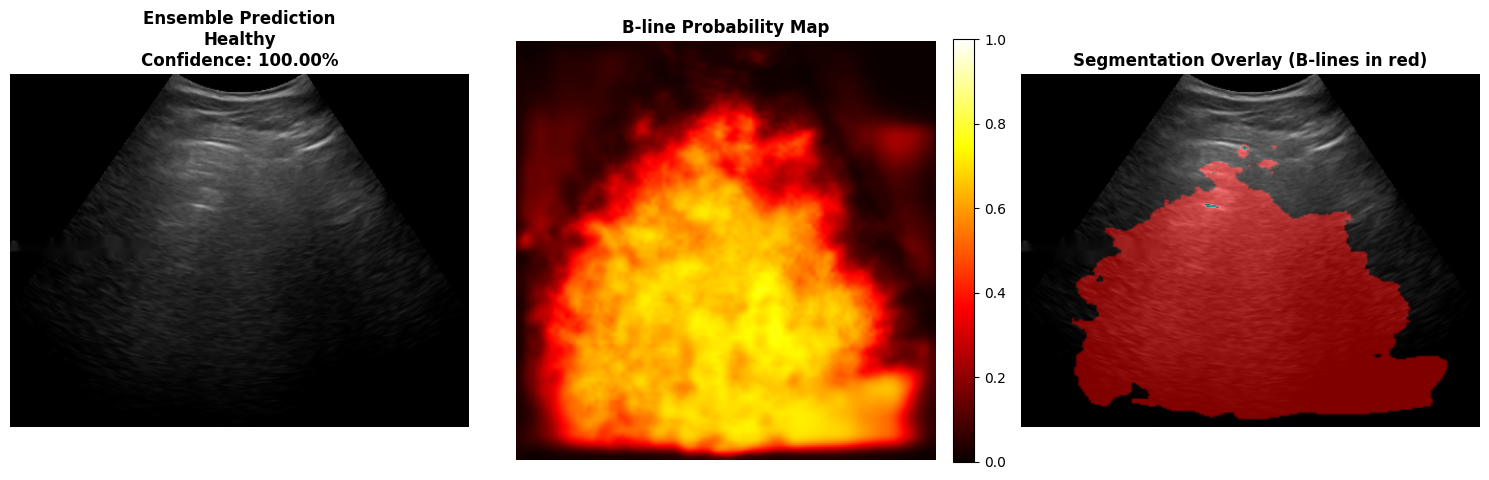


ENSEMBLE RESULTS
Prediction: Healthy
Confidence: 100.00%

Class Probabilities:
  COVID-19: 0.00%
  Other Disease: 0.00%
  Healthy: 100.00%

📷 Image 2: Healthy - image_48332634057726-12_1_14.png
True: Healthy → Pred: Healthy (✅ CORRECT)
Confidence: 100.00%
✅ Saved to: ./ensemble_results/result_2.png


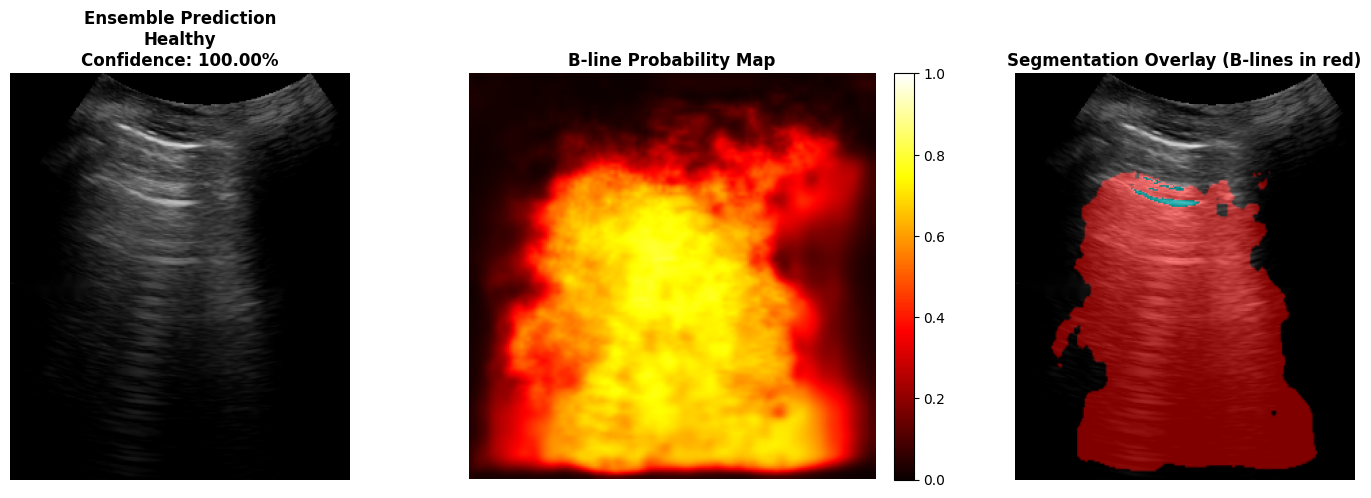


ENSEMBLE RESULTS
Prediction: Healthy
Confidence: 100.00%

Class Probabilities:
  COVID-19: 0.00%
  Other Disease: 0.00%
  Healthy: 100.00%

📷 Image 3: Healthy - image_5477068164787-11_16_46.png
True: Healthy → Pred: Healthy (✅ CORRECT)
Confidence: 100.00%
✅ Saved to: ./ensemble_results/result_3.png


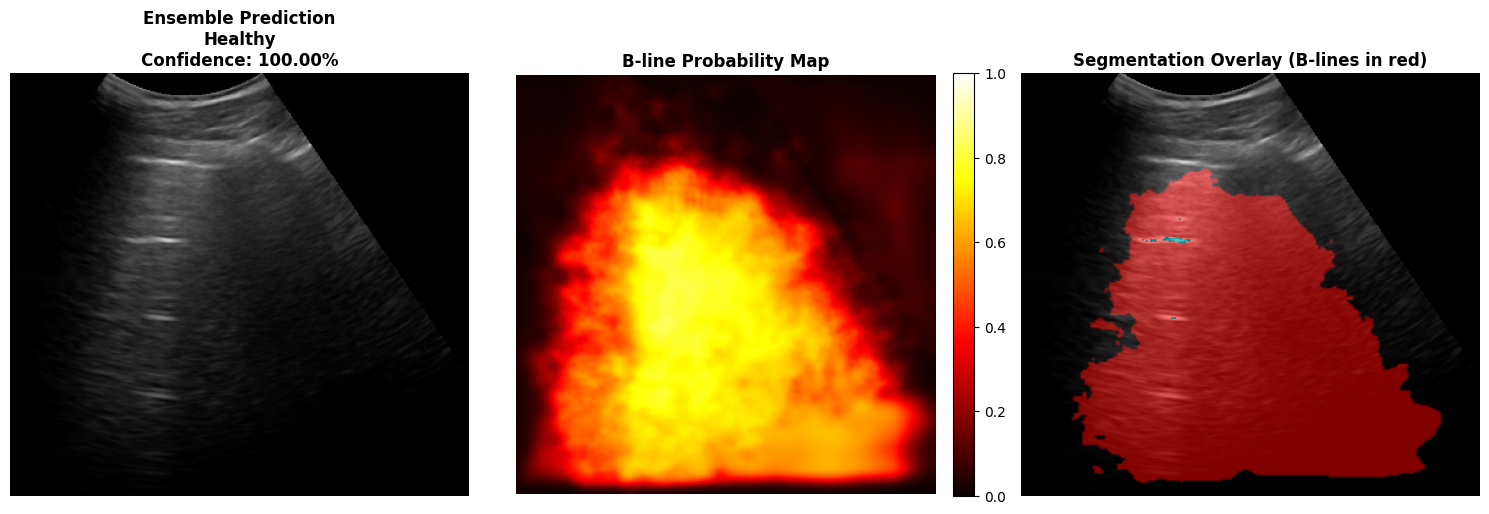


ENSEMBLE RESULTS
Prediction: Healthy
Confidence: 100.00%

Class Probabilities:
  COVID-19: 0.00%
  Other Disease: 0.00%
  Healthy: 100.00%

📷 Image 4: Healthy - image_5260512561235-12_53_19.png
True: Healthy → Pred: Healthy (✅ CORRECT)
Confidence: 100.00%
✅ Saved to: ./ensemble_results/result_4.png


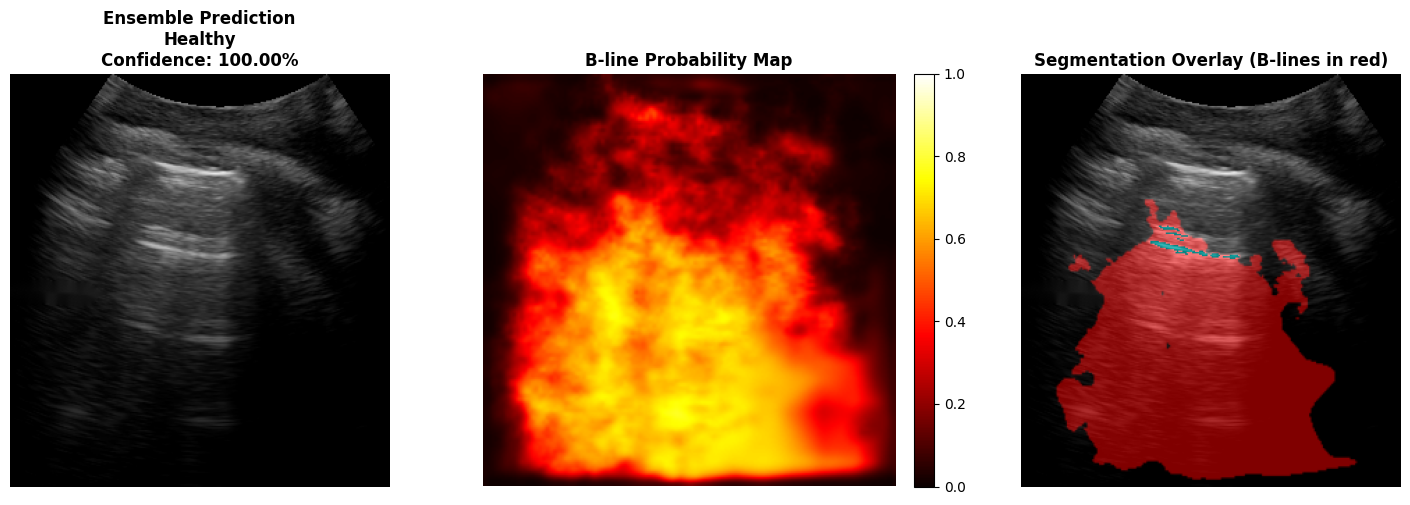


ENSEMBLE RESULTS
Prediction: Healthy
Confidence: 100.00%

Class Probabilities:
  COVID-19: 0.00%
  Other Disease: 0.00%
  Healthy: 100.00%

📷 Image 5: Healthy - image_3698897148604-9_19_19.png
True: Healthy → Pred: Healthy (✅ CORRECT)
Confidence: 100.00%
✅ Saved to: ./ensemble_results/result_5.png


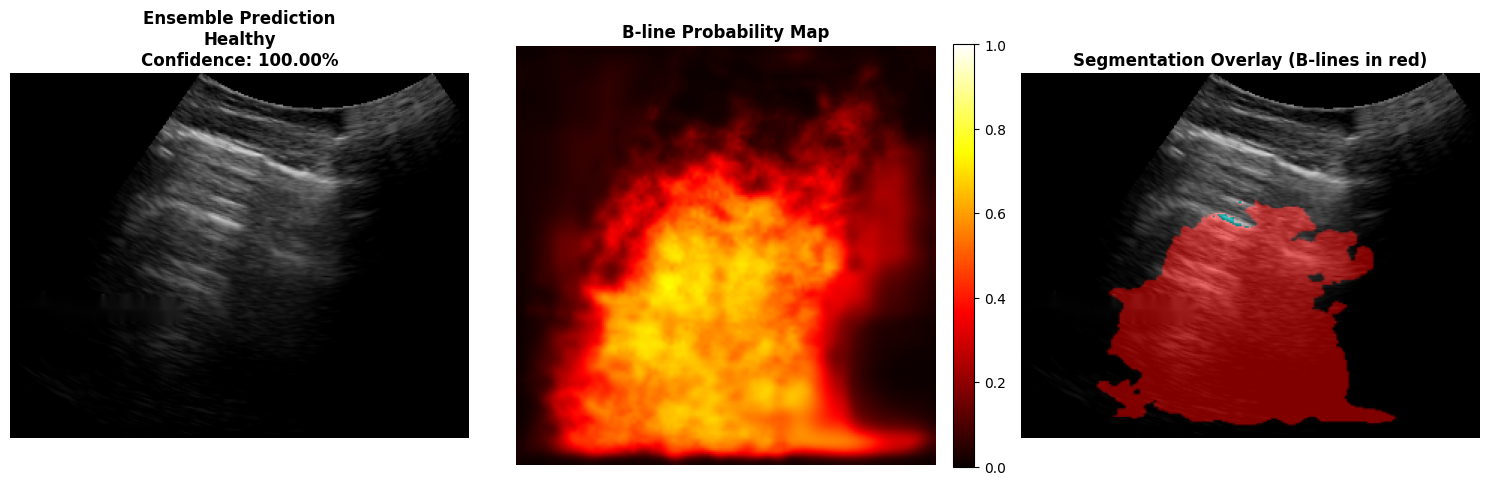


ENSEMBLE RESULTS
Prediction: Healthy
Confidence: 100.00%

Class Probabilities:
  COVID-19: 0.00%
  Other Disease: 0.00%
  Healthy: 100.00%

ACCURACY: 5/5 (100.0%)


In [7]:
# CELL 7: Test on Random Sample
if ensemble is not None and test_images:
    import random
    
    num_samples = min(5, len(test_images))
    sample_images = random.sample(test_images, num_samples)
    
    print("="*60)
    print("TESTING ENSEMBLE ON RANDOM IMAGES")
    print("="*60)
    
    correct = 0
    for i, img_info in enumerate(sample_images):
        print(f"\n📷 Image {i+1}: {img_info['true_label']} - {os.path.basename(img_info['path'])}")
        
        try:
            img_tensor, original, _ = preprocess_image(img_info['path'])
            img_tensor = img_tensor.to(device)
            
            with torch.no_grad():
                prediction = ensemble.predict(img_tensor)
            
            pred_class = CLASS_NAMES[prediction['class'].item()]
            is_correct = (pred_class == img_info['true_label'])
            if is_correct:
                correct += 1
            
            status = "✅ CORRECT" if is_correct else "❌ WRONG"
            print(f"True: {img_info['true_label']} → Pred: {pred_class} ({status})")
            print(f"Confidence: {prediction['confidence'].item():.2%}")
            
            display_ensemble_results(original, prediction, 
                                    save_path=f"./ensemble_results/result_{i+1}.png")
            
        except Exception as e:
            print(f"Error: {e}")
    
    print(f"\n{'='*60}")
    print(f"ACCURACY: {correct}/{len(sample_images)} ({correct/len(sample_images)*100:.1f}%)")
    print("="*60)

In [8]:
# CELL 9: Save Ensemble for Deployment
def save_ensemble_for_deployment(ensemble, save_path="./ensemble_model.pth"):
    """
    Save the ensemble model for later use
    """
    # Note: This saves the wrapper, not the individual models
    # For deployment, you need to save both models separately
    torch.save({
        'ensemble_state': ensemble.state_dict(),
        'model_l1_state': model_l1.state_dict(),
        'model5_state': model5.state_dict()
    }, save_path)
    print(f"✅ Ensemble saved to: {save_path}")


def load_ensemble_for_inference(model_l1_class, model5_class, checkpoint_path, device):
    """
    Load ensemble for inference
    """
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    model_l1 = model_l1_class(num_classes=3, num_seg_classes=1)
    model_l1.load_state_dict(checkpoint['model_l1_state'])
    model_l1.to(device)
    model_l1.eval()
    
    model5 = model5_class(num_classes=3, num_seg_classes=1)
    model5.load_state_dict(checkpoint['model5_state'])
    model5.to(device)
    model5.eval()
    
    ensemble = EnsembleModel(model_l1, model5)
    ensemble.load_state_dict(checkpoint['ensemble_state'])
    ensemble.to(device)
    ensemble.eval()
    
    return ensemble


# Uncomment to save
# if ensemble is not None:
#     save_ensemble_for_deployment(ensemble, "./ensemble_model.pth")

In [9]:
# CELL: Save Ensemble Model to Disk
import os

# Create directory if it doesn't exist
os.makedirs("./ensemble_models", exist_ok=True)

# Save path
ensemble_save_path = "./ensemble_models/ensemble_model.pth"

# Save the ensemble (both models' weights)
if 'ensemble' in locals() and ensemble is not None:
    torch.save({
        'model_l1_state_dict': model_l1.state_dict(),
        'model5_state_dict': model5.state_dict(),
        'ensemble_config': {
            'model_l1_class': 'ModelL1_EfficientNet_SegFormerLite',
            'model5_class': 'Model5_EfficientNet_SegFormer',
            'num_classes': 3,
            'num_seg_classes': 1
        }
    }, ensemble_save_path)
    print(f"✅ Ensemble saved to: {os.path.abspath(ensemble_save_path)}")
    
    # Check file size
    file_size = os.path.getsize(ensemble_save_path) / 1024 / 1024
    print(f"   File size: {file_size:.2f} MB")
else:
    print("❌ Ensemble not found in memory. Run the ensemble creation cells first.")

✅ Ensemble saved to: C:\Users\Administrator\ensemble_models\ensemble_model.pth
   File size: 60.09 MB
